Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Load Dataset

In [29]:
df = pd.read_csv("student_performance_prediction/StudentPerformanceFactors.csv")

In [31]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Dataset Information

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Statistical Analysis

In [37]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Check Missing Values

In [39]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Correlation Heatmap

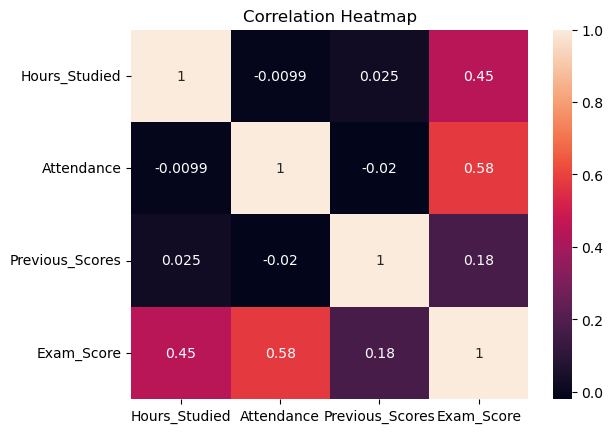

In [43]:
correlation = df[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score']].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

Feature Selection

In [92]:
X = df[['Hours_Studied', 'Attendance', 'Previous_Scores']]

y = df['Exam_Score']

Train Test Split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [96]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Predictions

In [49]:
predictions = model.predict(X_test)

predictions[:5]

array([66.02422558, 67.12132203, 68.68064739, 67.4221488 , 65.09835739])

Mean Absolute Error

In [51]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print(error)

1.3592073185897011


Accuracy Score

In [53]:
accuracy = r2_score(y_test, predictions)

print("R2 Score:", accuracy)

R2 Score: 0.6223383752199567


Visualization 1

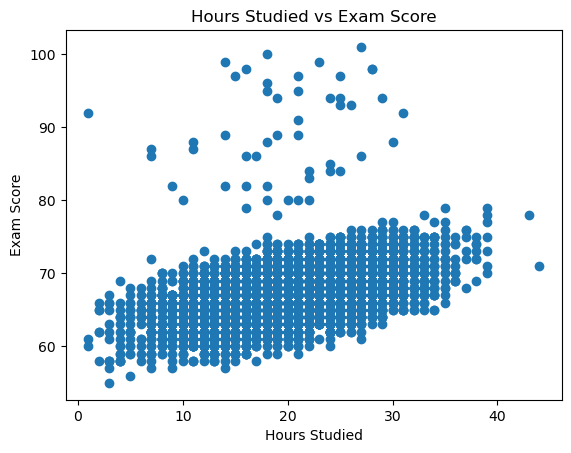

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Exam_Score'])

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.title("Hours Studied vs Exam Score")

plt.show()

Visualization 2

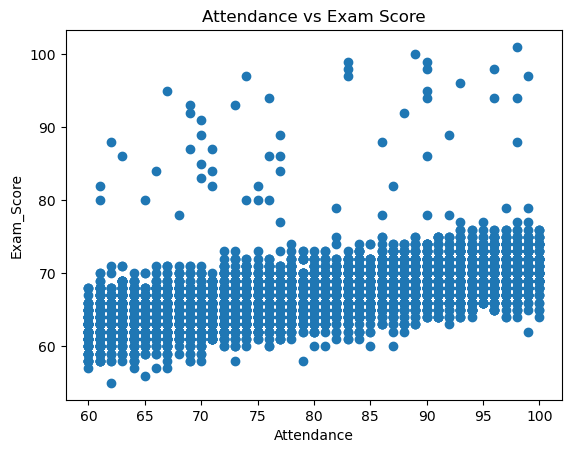

In [103]:
plt.scatter(df['Attendance'], df['Exam_Score'])

plt.xlabel("Attendance")
plt.ylabel("Exam_Score")

plt.title("Attendance vs Exam Score")

plt.show()

Custom Prediction

In [74]:
sample_data = pd.DataFrame({
    'Hours_Studied': [8],
    'Attendance': [90],
    'Previous_Scores': [85]
})
sample_prediction = model.predict(sample_data)

print("Predicted Exam Score:", sample_prediction[0])

Predicted Exam Score: 66.26287719767635


# Conclusion

The project successfully predicts student exam performance using Linear Regression based on study hours, attendance, and previous academic scores. The model demonstrates how machine learning can be used in educational analytics to identify performance trends.